In [3]:
#import des bibliothèques
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold

2021 : 17520 lignes | 2021-01-01 00:00:00 → 2021-12-31 23:30:00
2022 : 17520 lignes | 2022-01-01 00:00:00 → 2022-12-31 23:30:00
2023 : 17520 lignes | 2023-01-01 00:00:00 → 2023-12-31 23:30:00
Shape du fichier : (26280, 4)
             timestamp  vent_vitesse_kmh  vent_direction  vent_rafales_kmh
0  2021-01-01 00:00:00          8.266667      233.333333         15.208333
1  2021-01-01 01:00:00          6.600000      189.000000         15.658333
2  2021-01-01 02:00:00          6.558333      228.916667         14.400000
3  2021-01-01 03:00:00          6.850000      177.416667         14.250000
4  2021-01-01 04:00:00          6.858333      184.666667         14.575000
Vent : 26280 mesures | 2021-01-01 00:00:00 → 2023-12-31 23:00:00
Vent : 26280 mesures | 2021-01-01 00:00:00 → 2023-12-31 23:00:00
Après fusion : 13127 lignes

Modèle : Régression linéaire
  R² train          : 0.7228
  R² test           : 0.6430  ✓ Bon équilibre train/test
  RMSE              : 27804.43 MWh
  MAE              

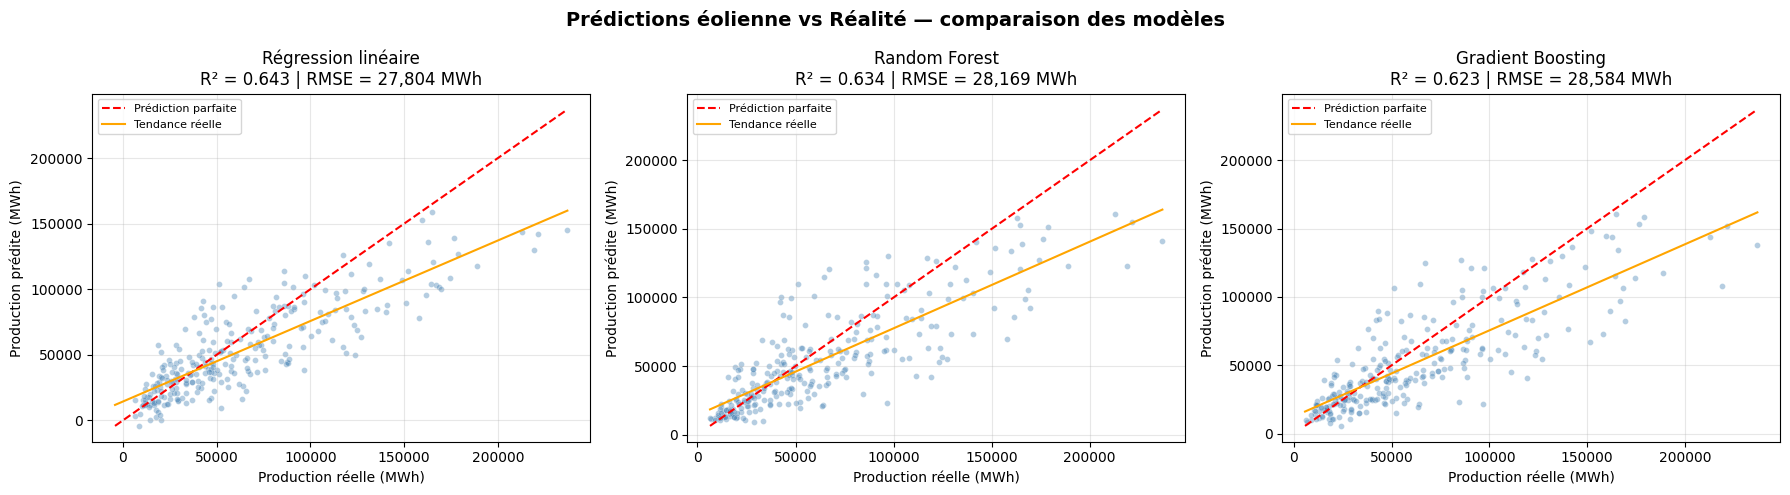

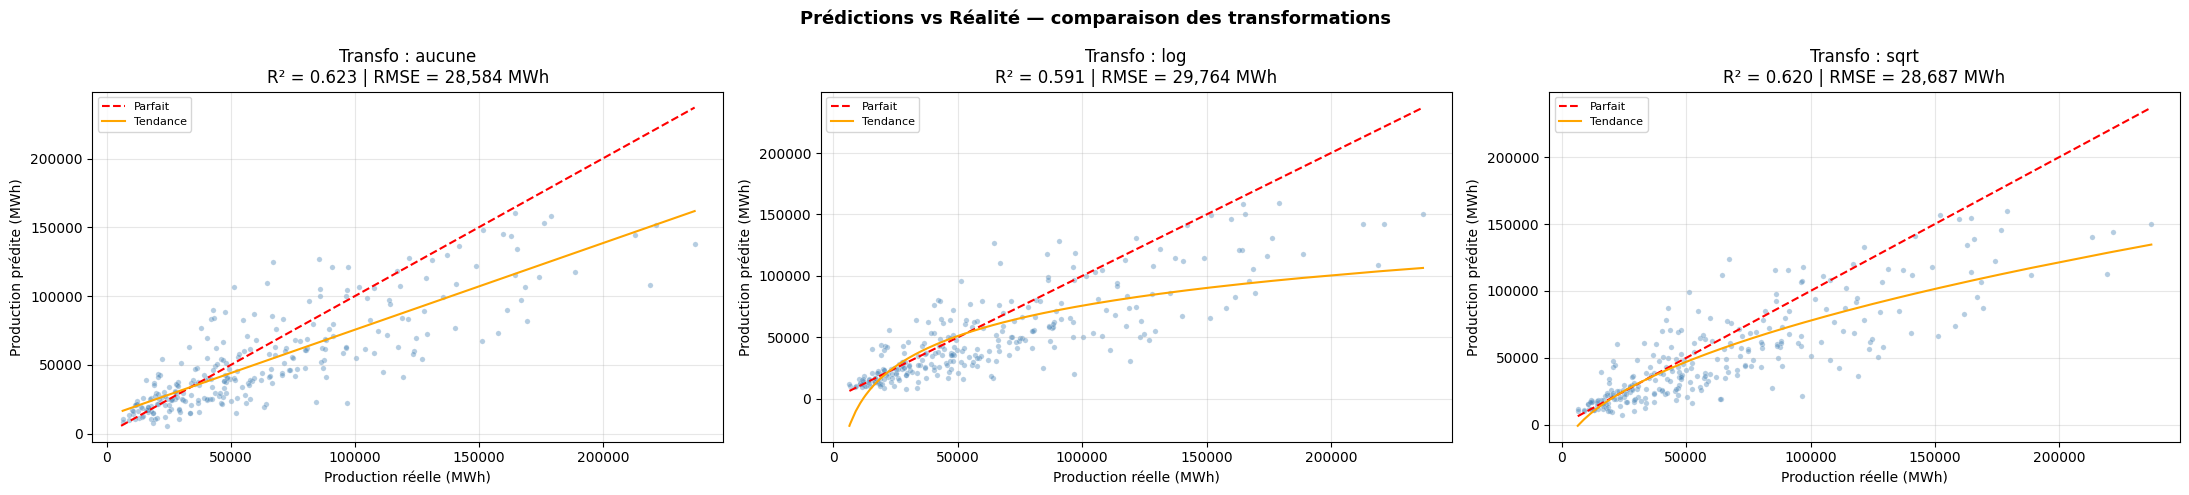

Graphique 1 sauvegardé


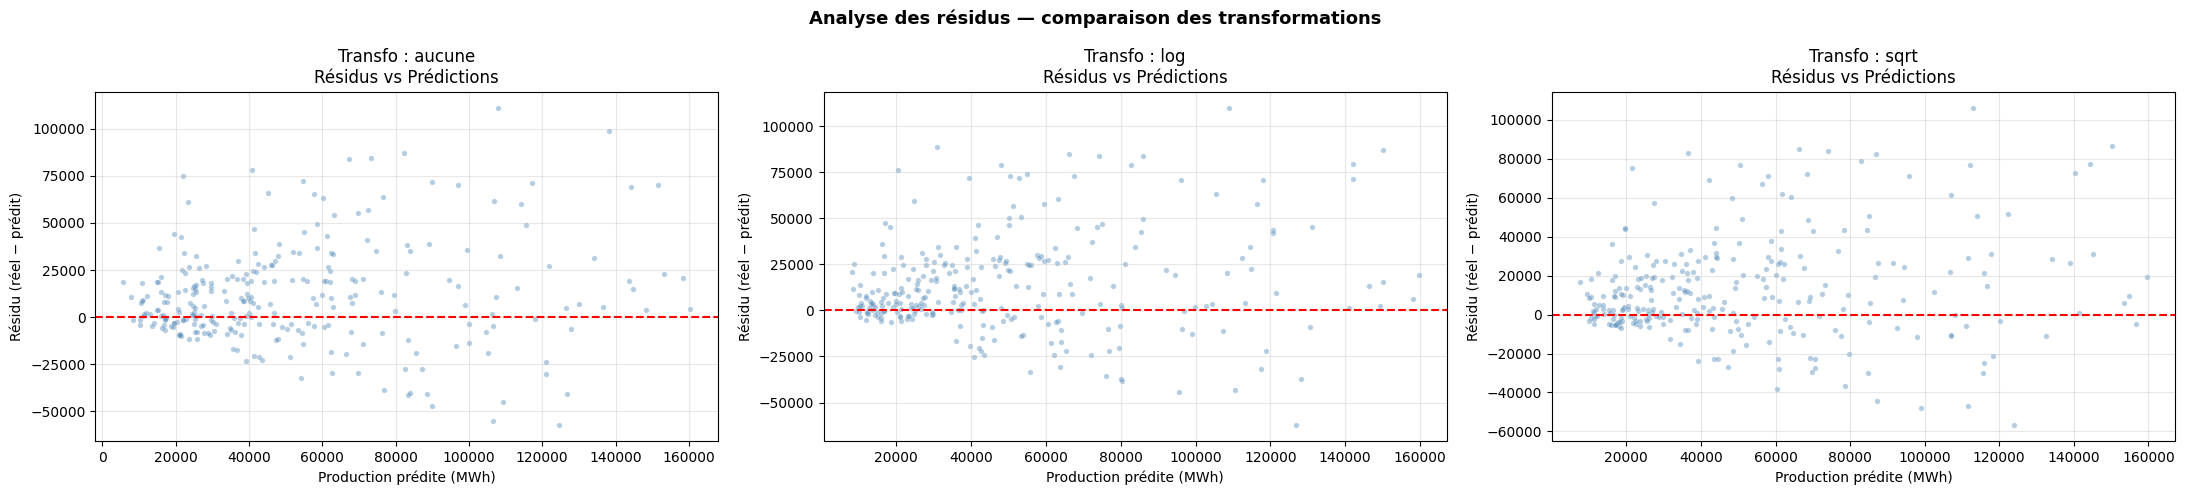

Graphique 2 sauvegardé
Graphique 2 sauvegardé
Graphique 3 sauvegardé


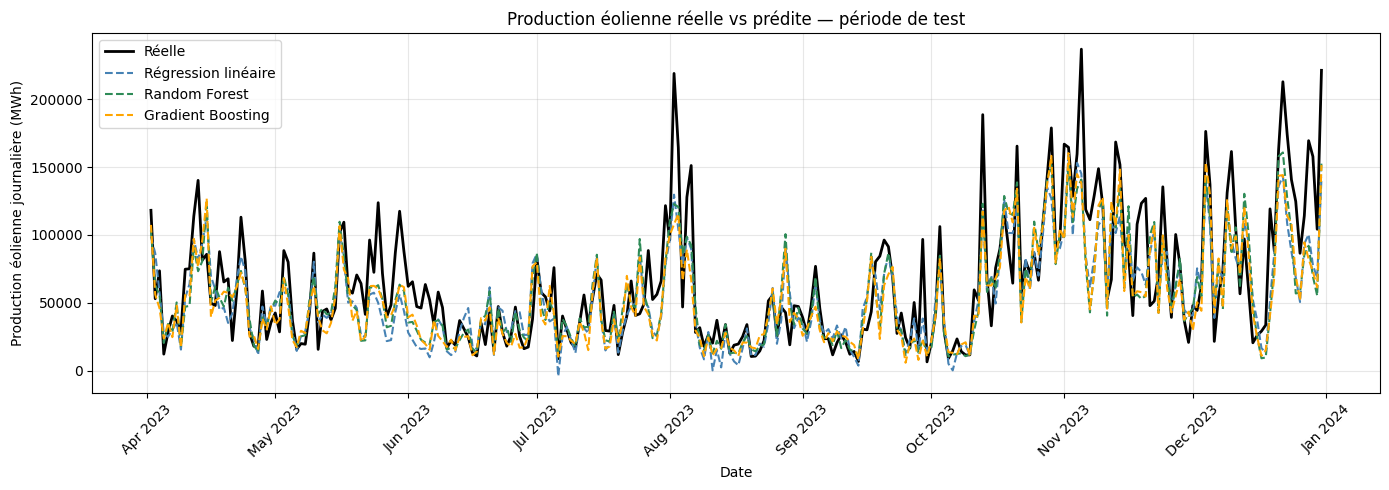

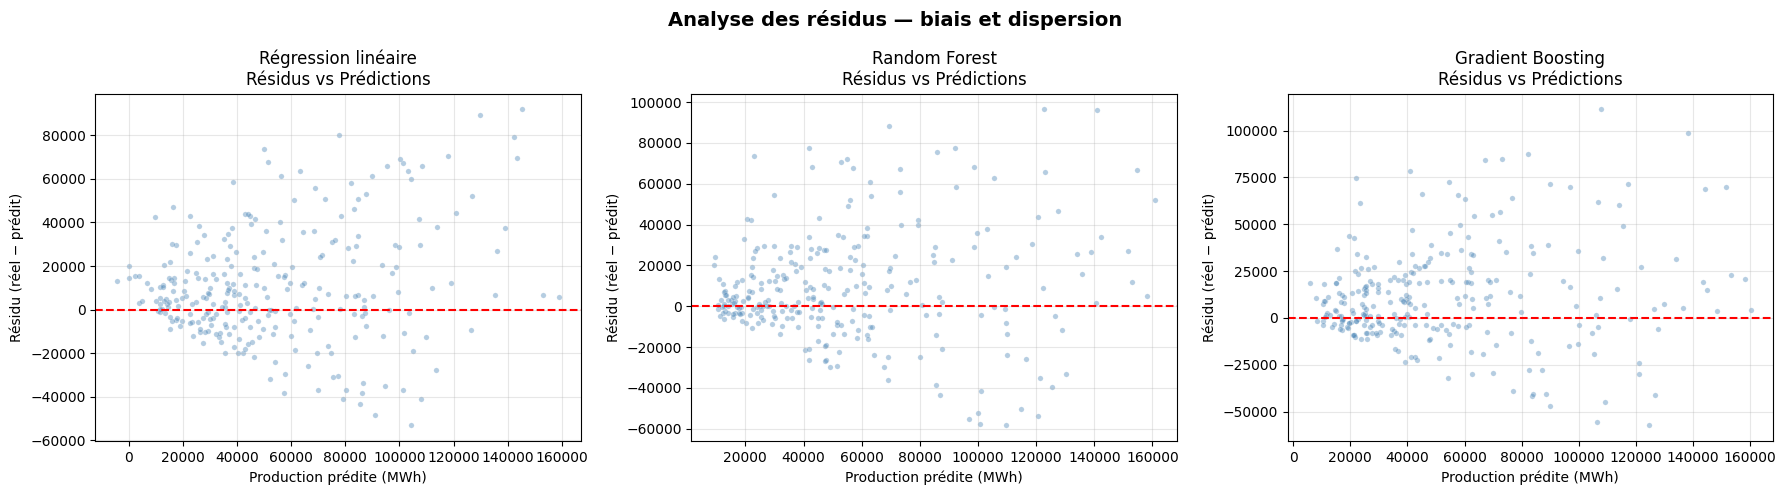

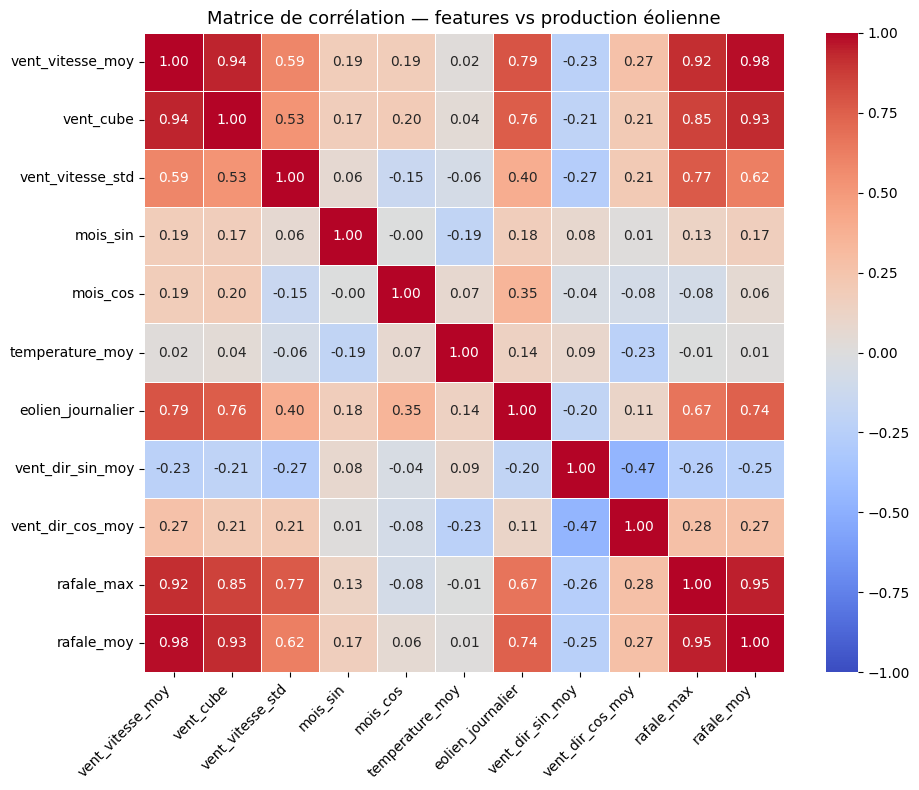

Matrice de corrélation sauvegardée


In [ ]:
#Nettoyage des données de vents
def donnee_vent():
    df_vent = pd.read_csv(f"data/vent_openmeteo_2021_2023.csv", sep=",")
    print("Shape du fichier :", df_vent.shape)
    print(df_vent.head())
    df_vent["timestamp"] = pd.to_datetime(df_vent["timestamp"])
    df_vent = df_vent[df_vent["timestamp"].dt.minute.isin([0, 30])].reset_index(drop=True)
    print(f"Vent : {len(df_vent)} mesures | {df_vent['timestamp'].min()} → {df_vent['timestamp'].max()}")

# Encodage cyclique de la direction du vent (évite le saut 359°→0°)
    # À adapter selon le nom exact de votre colonne direction
    df_vent["vent_dir_sin"] = np.sin(np.radians(df_vent["vent_direction"]))  # ← nom à adapter
    df_vent["vent_dir_cos"] = np.cos(np.radians(df_vent["vent_direction"]))  # ← nom à adapter

    print(f"Vent : {len(df_vent)} mesures | {df_vent['timestamp'].min()} → {df_vent['timestamp'].max()}")

    return df_vent
#données températures
def donnees_temp():
    donnees_temp = {
        "temperature": {}, 
        "rayonnement": {}, 
        "delta_temperature": {},
        "vent":        {}, 
        "timestamp":   {} 
    }
    annees = [2021, 2022, 2023]
    for annee in annees:
        df_temp = pd.read_csv(f"data/donnees-de-temperature-et-de-pseudo-rayonnement_{annee}.csv", sep=";")
        df_temp = df_temp.iloc[::2].reset_index(drop=True)
        
        df_temp["timestamp"] = pd.to_datetime(df_temp["Horodate"], utc=True).dt.tz_convert("Europe/Paris").dt.tz_localize(None)
        # Température normale
        donnees_temp["temperature"][annee] = df_temp["Température normale lissée (°C)"]
        #donnees_temp["temperature"][annee] = df_temp["Température réalisée lissée (°C)"]
        # Delta de température
        donnees_temp["delta_temperature"][annee] = df_temp["Température réalisée lissée - Température normale lissée (°C)"]
        donnees_temp["rayonnement"][annee]  = df_temp["Pseudo rayonnement (%)"]
        donnees_temp["timestamp"][annee]    = df_temp["timestamp"]
    return donnees_temp


# Données de production
def donnees_prod():
    donnees_prod = {
        "eolien":    {},
        "pv":        {},
        "hydro":     {},
        "timestamp": {}
    }
    annees = [2021, 2022, 2023]
    for annee in annees:
        df = pd.read_csv(
            f"Data/eCO2mix prod/eCO2mix_RTE_Annuel-Definitif_{annee}.xls",
            sep="\t",
            encoding="latin-1",
            low_memory=False,
            index_col=False
        )
        df = df[df["Heures"].astype(str).str.match(r"^\d{2}:(00|30)$")].reset_index(drop=True)
        df["timestamp"] = pd.to_datetime(
            df["Date"].astype(str).str.strip() + " " + df["Heures"].astype(str).str.strip(),
            errors="coerce"
        )
        df = df.dropna(subset=["timestamp"]).reset_index(drop=True)
        print(f"{annee} : {len(df)} lignes | {df['timestamp'].min()} → {df['timestamp'].max()}")
        donnees_prod["eolien"][annee]    = pd.to_numeric(df["Eolien"],      errors="coerce").reset_index(drop=True)
        donnees_prod["pv"][annee]        = pd.to_numeric(df["Solaire"],     errors="coerce").reset_index(drop=True)
        donnees_prod["hydro"][annee]     = pd.to_numeric(df["Hydraulique"], errors="coerce").reset_index(drop=True)
        donnees_prod["timestamp"][annee] = df["timestamp"].reset_index(drop=True)
    return donnees_prod


production = donnees_prod()
dfs = []
donnees_temp_dict = donnees_temp()
dfs_temp = []
for annee in [2021, 2022, 2023]:
    df_prod = pd.DataFrame({
        'timestamp': production['timestamp'][annee].values,
        'eolien':        production['eolien'][annee].values,
    })
    dfs.append(df_prod)
    df_temp = pd.DataFrame({
        "timestamp": donnees_temp_dict["timestamp"][annee].values,
        "delta_temperature": donnees_temp_dict["delta_temperature"][annee].values,
       
    })
    dfs_temp.append(df_temp)

df_temp_all = pd.concat(dfs_temp, ignore_index=True)
df_prod_all = pd.concat(dfs, ignore_index=True)
df_vent=donnee_vent()

# ── Fusion ────────────────────────────────────────────────────────────────────
#df_merge = pd.merge(df_vent, df_prod_all, on="timestamp", how="inner")
df_merge = pd.merge(df_vent, df_prod_all, on="timestamp", how="inner")
df_merge = pd.merge(df_merge, df_temp_all, on="timestamp", how="inner")
print(f"Après fusion : {len(df_merge)} lignes")

# ── Agrégation par jour ───────────────────────────────────────────────────────
df_merge["date"] = df_merge["timestamp"].dt.date
df_jour = df_merge.groupby("date").agg(
    eolien_journalier   = ("eolien",               "sum"),
    vent_vitesse_moy = ("vent_vitesse_kmh", "mean"),
    vent_vitesse_std = ("vent_vitesse_kmh", "std"),
    vent_vitesse_max = ("vent_vitesse_kmh", "max"),
    vent_vitesse_min = ("vent_vitesse_kmh", "min"),
    temperature_moy=("delta_temperature","mean"),
    vent_dir_sin_moy   = ("vent_dir_sin",    "mean"),
    vent_dir_cos_moy   = ("vent_dir_cos",    "mean"),
    rafale_max         = ("vent_rafales_kmh",  "max"),   
    rafale_moy         = ("vent_rafales_kmh",  "mean")
).reset_index()

df_jour["vent_vitesse_std"] = df_jour["vent_vitesse_std"].fillna(0)
df_jour["date"] = pd.to_datetime(df_jour["date"])

# ══════════════════════════════════════════════════════════════
# FEATURE ENGINEERING — à ajouter juste après l'agrégation
# df_jour est déjà calculé, on l'enrichit
# ══════════════════════════════════════════════════════════════

# 1. Loi physique : puissance ∝ v³  (le plus important !)
df_jour["vent_cube"]         = df_jour["vent_vitesse_moy"] ** 3
df_jour["vent_max_cube"]     = df_jour["vent_vitesse_max"] ** 3

# 2. Plage de vent (indicateur de régularité)
df_jour["vent_range"]        = df_jour["vent_vitesse_max"] - df_jour["vent_vitesse_min"]

# 3. Saisonnalité — très corrélée à la production éolienne en France
df_jour["mois"]              = df_jour["date"].dt.month
df_jour["jour_annee"]        = df_jour["date"].dt.dayofyear

# Encodage cyclique pour mois (évite le saut 12→1)
df_jour["mois_sin"]          = np.sin(2 * np.pi * df_jour["mois"] / 12)
df_jour["mois_cos"]          = np.cos(2 * np.pi * df_jour["mois"] / 12)

# 4. Indicateur de tempête (vent très fort → coupure de sécurité des éoliennes)
# Au-delà de ~90 km/h les éoliennes s'arrêtent → relation non-monotone
df_jour["vent_fort"]         = (df_jour["vent_vitesse_max"] > 80).astype(int)

# ══════════════════════════════════════════════════════════════
# NOUVELLES FEATURES — remplace votre X actuel
# ══════════════════════════════════════════════════════════════

features = [
    "vent_vitesse_moy",
    "vent_vitesse_max",
    "vent_vitesse_min",
    "vent_vitesse_std",
    "vent_range",
    "vent_cube",           # ← clé physique
    "vent_max_cube",       # ← clé physique
    "temperature_moy",
    "mois_sin",            # ← saisonnalité
    "mois_cos",
    "vent_fort",           # ← coupure de sécurité
    "vent_dir_sin_moy",
    "vent_dir_cos_moy",
    "rafale_max",   
    "rafale_moy"  
]

X = df_jour[features]
y = df_jour["eolien_journalier"]

# ══════════════════════════════════════════════════════════════
# SPLIT — inchangé (correct pour série temporelle)
# ══════════════════════════════════════════════════════════════

train_size   = int(0.75 * len(df_jour))
X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test,  y_test  = X.iloc[train_size:], y.iloc[train_size:]

# ══════════════════════════════════════════════════════════════
# MODÈLES AMÉLIORÉS
# ══════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit  # ← remplace KFold

# TimeSeriesSplit respecte l'ordre chronologique — bien plus fiable que KFold
tscv = TimeSeriesSplit(n_splits=5)

modeles = {
    "Régression linéaire": Pipeline([
        ("scaler", StandardScaler()),           # normalisation obligatoire
        ("model",  LinearRegression())
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,                     # évite l'overfitting
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,                     # plus lent mais plus précis
        max_depth=4,
        subsample=0.8,                          # stochastic GB → régularisation
        min_samples_leaf=5,
        random_state=42
    ),
}

# ══════════════════════════════════════════════════════════════
# ÉVALUATION — même structure que votre code, avec TimeSeriesSplit
# ══════════════════════════════════════════════════════════════

resultats = {}
for nom, model in modeles.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test,  y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae      = mean_absolute_error(y_test, y_pred_test)

    # Cross-validation temporelle (remplace KFold shuffle=False)
    scores = cross_val_score(model, X, y, cv=tscv, scoring="r2")

    resultats[nom] = {
        "r2_train": r2_train,
        "r2_test":  r2_test,
        "rmse":     rmse,
        "mae":      mae,
        "cv_mean":  scores.mean(),
        "cv_std":   scores.std(),
        "y_pred":   y_pred_test
    }

    if r2_train - r2_test > 0.1:
        statut = "⚠ Overfitting détecté"
    elif r2_test < 0.4:
        statut = "⚠ Underfitting détecté"
    else:
        statut = "✓ Bon équilibre train/test"

    print(f"\n{'='*45}")
    print(f"Modèle : {nom}")
    print(f"{'='*45}")
    print(f"  R² train          : {r2_train:.4f}")
    print(f"  R² test           : {r2_test:.4f}  {statut}")
    print(f"  RMSE              : {rmse:.2f} MWh")
    print(f"  MAE               : {mae:.2f} MWh")
    print(f"  CV R² moyen       : {scores.mean():.4f}")
    print(f"  CV écart-type     : {scores.std():.4f}")
    print(f"  CV R² par pli     : {[round(s, 3) for s in scores]}")

# ── Graphique 1 — Prédictions vs Réalité (scatter) ───────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nom, res) in zip(axes, resultats.items()):
    r2    = res["r2_test"]
    y_min = min(y_test.min(), res["y_pred"].min())
    y_max = max(y_test.max(), res["y_pred"].max())

    sns.scatterplot(x=y_test, y=res["y_pred"], alpha=0.4, s=18, ax=ax, color="steelblue")
    ax.plot([y_min, y_max], [y_min, y_max], 'r--', linewidth=1.5, label="Prédiction parfaite")

    # Droite de tendance
    z = np.polyfit(y_test, res["y_pred"], 1)
    p = np.poly1d(z)
    ax.plot([y_min, y_max], p([y_min, y_max]), "orange", linewidth=1.5, linestyle="-", label="Tendance réelle")

    ax.set_xlabel("Production réelle (MWh)")
    ax.set_ylabel("Production prédite (MWh)")
    ax.set_title(f"{nom}\nR² = {r2:.3f} | RMSE = {res['rmse']:,.0f} MWh")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Prédictions éolienne vs Réalité — comparaison des modèles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graph1_predictions_eolienne.png", dpi=150)
print("Graphique 1 sauvegardé")

#___________________________________________________________________________________________________________________
# TEST PREDICTION LOGARITHME ET RACINE CARRE
#___________________________________________________________________________________________________________________
from scipy.stats import boxcox
from scipy.special import inv_boxcox

transformations = {
    "aucune": (y,                    lambda p: p),
    "log":    (np.log1p(y),          lambda p: np.expm1(p)),
    "sqrt":   (np.sqrt(y),           lambda p: np.clip(p ** 2, 0, None)),
}

resultats_transfo = {}

for nom_transfo, (y_transfo, retransfo) in transformations.items():

    X_train_ = X.iloc[:train_size]
    y_train_ = y_transfo.iloc[:train_size]
    X_test_  = X.iloc[train_size:]
    y_test_  = y_transfo.iloc[train_size:]

    model = GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.05,
        max_depth=4, subsample=0.8,
        min_samples_leaf=5, random_state=42
    )
    model.fit(X_train_, y_train_)
    y_pred_transfo  = model.predict(X_test_)

    # Retransformation dans l'espace original
    y_pred_original = retransfo(y_pred_transfo)
    y_test_original = y.iloc[train_size:]

    r2   = r2_score(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae  = mean_absolute_error(y_test_original, y_pred_original)

    resultats_transfo[nom_transfo] = {"r2": r2, "rmse": rmse, "mae": mae}
    print(f"\nTransformation : {nom_transfo}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:,.0f} MWh")
    print(f"  MAE  : {mae:,.0f} MWh")

# ── À ajouter avant les graphiques 2 et 3 ────────────────────
noms_transfo    = list(resultats_transfo.keys())
y_test_original = y.iloc[train_size:]

# ── Graphique 2 — Prédictions vs Réalité pour chaque transformation
from scipy.stats import boxcox
from scipy.special import inv_boxcox



transformations = {
    "aucune": (y,               lambda p: p),
    "log":    (np.log1p(y),     lambda p: np.expm1(p)),
    "sqrt":   (np.sqrt(y),      lambda p: np.clip(p ** 2, 0, None)),
   
}

noms_transfo    = list(transformations.keys())
y_test_original = y.iloc[train_size:]

# ── Courbes de tendance adaptées ──────────────────────────────
tendances = {
    "aucune": lambda x, y: np.poly1d(np.polyfit(x, y, 1))(x),
    "log":    lambda x, y: np.poly1d(np.polyfit(np.log(x + 1), y, 1))(np.log(x + 1)),
    "sqrt":   lambda x, y: np.poly1d(np.polyfit(np.sqrt(x), y, 1))(np.sqrt(x)),
 }
# ── Entraînement et prédictions ───────────────────────────────
predictions = {}
for transfo in noms_transfo:
    y_transfo, retransfo = transformations[transfo]
    model = GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.05,
        max_depth=4, subsample=0.8,
        min_samples_leaf=5, random_state=42
    )
    model.fit(X.iloc[:train_size], y_transfo.iloc[:train_size])
    y_pred_transfo  = model.predict(X.iloc[train_size:])
    y_pred_original = retransfo(y_pred_transfo)
    predictions[transfo] = y_pred_original

# ── Graphique 1 — Prédictions vs Réalité ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, transfo in zip(axes, noms_transfo):
    y_pred_original = predictions[transfo]

    y_min = min(y_test_original.min(), y_pred_original.min())
    y_max = max(y_test_original.max(), y_pred_original.max())

    sns.scatterplot(x=y_test_original, y=y_pred_original,
                    alpha=0.4, s=15, ax=ax, color="steelblue")
    ax.plot([y_min, y_max], [y_min, y_max],
            'r--', linewidth=1.5, label="Parfait")

    # Courbe de tendance adaptée à la transformation
    idx_sort = np.argsort(y_test_original.values)
    x_sorted = y_test_original.values[idx_sort]
    y_tend   = tendances[transfo](y_test_original.values, y_pred_original)[idx_sort]
    ax.plot(x_sorted, y_tend, "orange", linewidth=1.5, label="Tendance")

    r2   = r2_score(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    ax.set_title(f"Transfo : {transfo}\nR² = {r2:.3f} | RMSE = {rmse:,.0f} MWh")
    ax.set_xlabel("Production réelle (MWh)")
    ax.set_ylabel("Production prédite (MWh)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Prédictions vs Réalité — comparaison des transformations",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("graph_transformations_scatter.png", dpi=150)
plt.show()
print("Graphique 1 sauvegardé")

# ── Graphique 2 — Résidus ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, transfo in zip(axes, noms_transfo):
    y_pred_original = predictions[transfo]
    residus         = y_test_original.values - y_pred_original

    sns.scatterplot(x=y_pred_original, y=residus,
                    alpha=0.4, s=15, ax=ax, color="steelblue")
    ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
    ax.set_xlabel("Production prédite (MWh)")
    ax.set_ylabel("Résidu (réel − prédit)")
    ax.set_title(f"Transfo : {transfo}\nRésidus vs Prédictions")
    ax.grid(True, alpha=0.3)

plt.suptitle("Analyse des résidus — comparaison des transformations",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("graph_transformations_residus.png", dpi=150)
plt.show()
print("Graphique 2 sauvegardé")

# ── Graphique 2 — Série temporelle (tous les modèles) ─────────
dates_test = df_jour["date"].iloc[train_size:].values

plt.figure(figsize=(14, 5))
sns.lineplot(x=dates_test, y=y_test.values,              label="Réelle",               linewidth=2,   color="black")
sns.lineplot(x=dates_test, y=resultats["Régression linéaire"]["y_pred"], label="Régression linéaire", linewidth=1.5, linestyle="--", color="steelblue")
sns.lineplot(x=dates_test, y=resultats["Random Forest"]["y_pred"],       label="Random Forest",       linewidth=1.5, linestyle="--", color="seagreen")
sns.lineplot(x=dates_test, y=resultats["Gradient Boosting"]["y_pred"],   label="Gradient Boosting",   linewidth=1.5, linestyle="--", color="orange")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Production éolienne journalière (MWh)")
plt.title("Production éolienne réelle vs prédite — période de test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("graph2__eolien_serie_temporelle.png", dpi=150)
print("Graphique 2 sauvegardé")

# ── Graphique 3 — Résidus ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nom, res) in zip(axes, resultats.items()):
    residus = y_test.values - res["y_pred"]
    sns.scatterplot(x=res["y_pred"], y=residus, alpha=0.4, s=15, ax=ax, color="steelblue")
    ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
    ax.set_xlabel("Production prédite (MWh)")
    ax.set_ylabel("Résidu (réel − prédit)")
    ax.set_title(f"{nom}\nRésidus vs Prédictions")
    ax.grid(True, alpha=0.3)

plt.suptitle("Analyse des résidus — biais et dispersion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graph3_eolien_residus.png", dpi=150)
print("Graphique 3 sauvegardé")

##Matrice de corrélation
variables = [
    "vent_vitesse_moy",
    "vent_cube",
    #"vent_max_cube",
    #"vent_vitesse_max",
    "vent_vitesse_std",
    #"vent_range",
    "mois_sin",
    "mois_cos",
    "temperature_moy",
    "eolien_journalier",
    "vent_dir_sin_moy",
    "vent_dir_cos_moy",
    "rafale_max",   
    "rafale_moy"
]
corr = df_jour[variables].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,          # affiche les valeurs
    fmt=".2f",           # 2 décimales
    cmap="coolwarm",     # rouge = corrélation positive, bleu = négative
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title("Matrice de corrélation — features vs production éolienne", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("graph_eolien_correlation.png", dpi=150)
plt.show()
print("Matrice de corrélation sauvegardée")